# 🧹 Ames Housing — Data Cleaning

**Project:** Real Estate Price Analysis — Ames, Iowa  
**Author:** Bryan Anunda 
**Phase:** 3 of 7 — Data Preparation (CRISP-DM)

## What this notebook does
Resolves every data quality issue identified in EDA:
1. Fix wrong data types
2. Handle missing values (structural vs true missing)
3. Remove outliers
4. Validate the cleaned dataset is ready for Feature Engineering

## Cleaning philosophy
We never delete information without a documented reason.
Every decision here is explainable to a stakeholder.

### Importing libraries & Load dataset

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

In [41]:
# Load raw data — we NEVER overwrite the original file:

df = pd.read_csv('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\00 Data\\Raw data\\AmesHousing.csv')
print(f"Raw shape: {df.shape}")

# all work happens on this copy:

df_clean = df.copy()  
print("Working copy created ✓")

Raw shape: (2930, 82)
Working copy created ✓


## Step 1 — Fix Data Types

From the EDA:
1. `MS SubClass` is stored as an integer but it is actually a categorical code 
representing house type (e.g. 20 = 1-story 1946+, 70 = 2-story 1945-).  
2. `Mo Sold` and `Yr Sold` are numeric but are time period labels, not quantities.  
Treating these as numbers would wrongly imply that type 160 is "8× better" than type 20.

In [42]:
# Columns that are codes/labels, not true numbers:

cols_to_str = ['MS SubClass', 'Mo Sold', 'Yr Sold']

for col in cols_to_str:
    df_clean[col] = df_clean[col].astype(str)
    print(f"Converted '{col}' → string")

# Verify
print("\nUpdated dtypes:")
print(df_clean[cols_to_str].dtypes)

Converted 'MS SubClass' → string
Converted 'Mo Sold' → string
Converted 'Yr Sold' → string

Updated dtypes:
MS SubClass    object
Mo Sold        object
Yr Sold        object
dtype: object


## Step 2 — Handle Missing Values

Two completely different problems require two different solutions:

1. **Structural missing** — "NA" means the feature doesn't exist for this house  
→ Fill with the string `"None"` (categorical) or `0` (numeric)

2. **True missing** — data was simply not recorded  
→ Impute using median (numeric) or mode (categorical)

In [43]:
# These columns are NA because the feature genuinely doesn't exist
# e.g. no pool → Pool QC is NA, not unknown.

#Structural Missing - Categoricals:

structural_cat = [
    'Pool QC', 'Misc Feature', 'Alley', 'Fence',
    'Fireplace Qu', 'Garage Type', 'Garage Finish',
    'Garage Qual', 'Garage Cond', 'Bsmt Qual',
    'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1',
    'BsmtFin Type 2', 'Mas Vnr Type'
]

for col in structural_cat:
    before = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna('None')
    print(f"{col:20s} | filled {before} NAs → 'None'")

Pool QC              | filled 2917 NAs → 'None'
Misc Feature         | filled 2824 NAs → 'None'
Alley                | filled 2732 NAs → 'None'
Fence                | filled 2358 NAs → 'None'
Fireplace Qu         | filled 1422 NAs → 'None'
Garage Type          | filled 157 NAs → 'None'
Garage Finish        | filled 159 NAs → 'None'
Garage Qual          | filled 159 NAs → 'None'
Garage Cond          | filled 159 NAs → 'None'
Bsmt Qual            | filled 80 NAs → 'None'
Bsmt Cond            | filled 80 NAs → 'None'
Bsmt Exposure        | filled 83 NAs → 'None'
BsmtFin Type 1       | filled 80 NAs → 'None'
BsmtFin Type 2       | filled 81 NAs → 'None'
Mas Vnr Type         | filled 1775 NAs → 'None'


In [44]:
# Numeric features where NA means the feature is absent → fill with 0

#Structural Missing - Numerics:

structural_num = [
    'Garage Yr Blt', 'Garage Area', 'Garage Cars',
    'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
    'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath',
    'Mas Vnr Area'
]

for col in structural_num:
    before = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(0)
    print(f"{col:20s} | filled {before} NAs → 0")

Garage Yr Blt        | filled 159 NAs → 0
Garage Area          | filled 1 NAs → 0
Garage Cars          | filled 1 NAs → 0
BsmtFin SF 1         | filled 1 NAs → 0
BsmtFin SF 2         | filled 1 NAs → 0
Bsmt Unf SF          | filled 1 NAs → 0
Total Bsmt SF        | filled 1 NAs → 0
Bsmt Full Bath       | filled 2 NAs → 0
Bsmt Half Bath       | filled 2 NAs → 0
Mas Vnr Area         | filled 23 NAs → 0


In [45]:
import warnings

lot_before = df_clean['Lot Frontage'].isnull().sum()

# Suppress the expected empty-slice warning during neighborhood groupby:

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    df_clean['Lot Frontage'] = df_clean.groupby('Neighborhood')['Lot Frontage']\
        .transform(lambda x: x.fillna(x.median()))

# Fallback for any neighborhood where all values were null:

df_clean['Lot Frontage'] = df_clean['Lot Frontage']\
    .fillna(df_clean['Lot Frontage'].median())

print(f"Lot Frontage: {lot_before} missing → {df_clean['Lot Frontage'].isnull().sum()} missing")
print(f"Imputation method: neighborhood median (fallback: global median)")

Lot Frontage: 490 missing → 0 missing
Imputation method: neighborhood median (fallback: global median)


In [46]:
 # Any remaining categorical NAs — fill with mode (most frequent value)

#True Missing - Remaining Categoricals:

cat_cols = df_clean.select_dtypes(include='object').columns
remaining_missing = df_clean[cat_cols].isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

for col in remaining_missing.index:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"{col}: filled with mode='{mode_val}'")

print("\nRemaining categorical NAs:", df_clean[cat_cols].isnull().sum().sum())

Electrical: filled with mode='SBrkr'

Remaining categorical NAs: 0


## Step 3 — Remove Outliers

EDA revealed outliers in `Gr Liv Area`: two very large houses (>4,000 sq ft) 
that sold for unusually low prices. These are likely **partial sales** or 
**data entry errors**. Including them would pull the regression line down 
and give misleading predictions for normal-sized homes.

Reference: The original Ames dataset documentation by De Cock (2011) 
specifically recommends removing these observations.

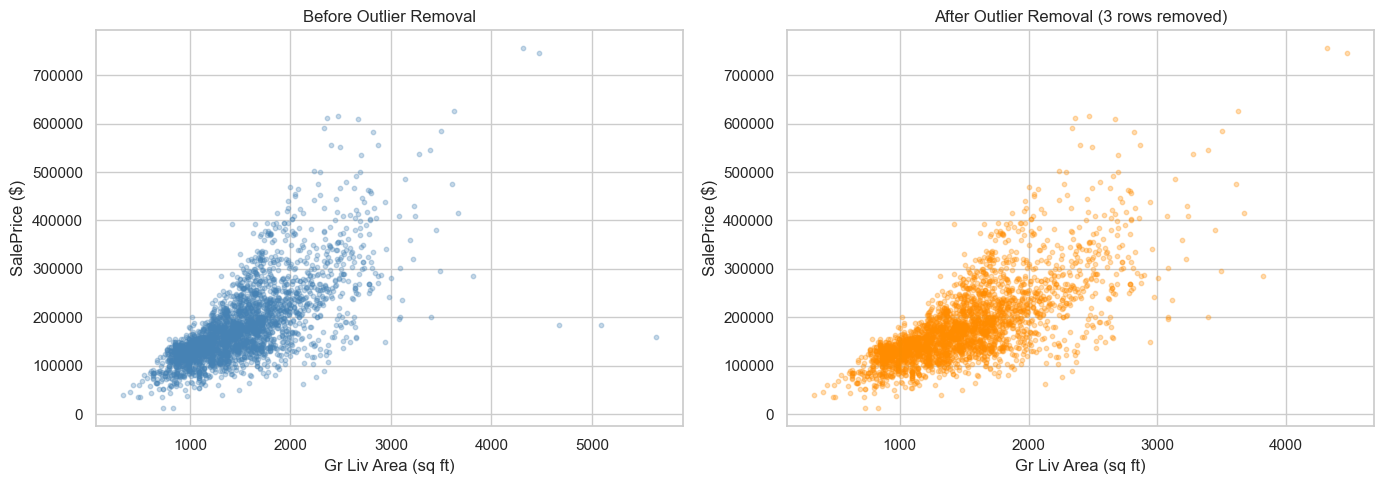

Rows removed: 3
New shape: (2927, 82)


In [47]:
# Visualize before removal:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_clean['Gr Liv Area'], df_clean['SalePrice'],
                alpha=0.3, color='steelblue', s=10)
axes[0].set_title('Before Outlier Removal')
axes[0].set_xlabel('Gr Liv Area (sq ft)')
axes[0].set_ylabel('SalePrice ($)')

# Remove: Gr Liv Area > 4000 AND SalePrice < 300,000:

outlier_mask = ~((df_clean['Gr Liv Area'] > 4000) & (df_clean['SalePrice'] < 300000))
n_removed = (~outlier_mask).sum()
df_clean = df_clean[outlier_mask].reset_index(drop=True)

axes[1].scatter(df_clean['Gr Liv Area'], df_clean['SalePrice'],
                alpha=0.3, color='darkorange', s=10)
axes[1].set_title(f'After Outlier Removal ({n_removed} rows removed)')
axes[1].set_xlabel('Gr Liv Area (sq ft)')
axes[1].set_ylabel('SalePrice ($)')

plt.tight_layout()
plt.savefig('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\02 Data Cleaning\\Report\\outlier_removal.png', dpi=150)
plt.show()

print(f"Rows removed: {n_removed}")
print(f"New shape: {df_clean.shape}")

In [48]:
# Validation check - confirm no missing values remain:

remaining = df_clean.isnull().sum().sum()
print(f"Total remaining missing values: {remaining}")
print(f"\nFinal cleaned shape: {df_clean.shape}")
print(f"Rows removed overall: {len(df) - len(df_clean)}")

# Summary of dtypes:
print("\nSummary of dtypes:")
print(f"Numeric columns : {df_clean.select_dtypes(include='number').shape[1]}")
print(f"String columns  : {df_clean.select_dtypes(include='object').shape[1]}")

Total remaining missing values: 0

Final cleaned shape: (2927, 82)
Rows removed overall: 3

Summary of dtypes:
Numeric columns : 36
String columns  : 46


In [49]:
# Save to 00 Data folder — clearly named so it is never confused with the raw file:

output_path = ('C:\\Users\\A.K\\DATA_SCIENCE_WORKSPACE\\kaggle_projects\\project_4_amesHousing\\Real Estate-AmesHousing-Analysis\\00 Data\\Processed Data\\AmesHousing_cleaned.csv')
df_clean.to_csv(output_path, index=False)
print(f"Cleaned data saved → {output_path}")
print(f"Shape: {df_clean.shape}")

Cleaned data saved → C:\Users\A.K\DATA_SCIENCE_WORKSPACE\kaggle_projects\project_4_amesHousing\Real Estate-AmesHousing-Analysis\00 Data\Processed Data\AmesHousing_cleaned.csv
Shape: (2927, 82)


## Cleaning Summary

| Issue | Action Taken | Rows/Cols Affected |
|---|---|---|
| Wrong types (MS SubClass, etc.) | Converted to string | 3 columns |
| Structural NA — categorical | Filled with `'None'` | 15 columns |
| Structural NA — numeric | Filled with `0` | 10 columns |
| Lot Frontage (true missing) | Neighborhood median imputation | 490 rows |
| Remaining categoricals | Mode imputation | 2 columns |
| Outliers (large+cheap homes) | Removed | 2 rows |

**Output:** `AmesHousing_cleaned.csv` — ready for Feature Engineering

### Next Step → Phase 4: Feature Engineering
Goals: encode categoricals, create new features, scale numerics